In [1]:
import os
from dotenv import load_dotenv  # Carrega variáveis de ambiente do arquivo .env
import dspy  # Framework para otimização de prompts com Language Models

from IPython.display import Image, display  # Ferramentas para exibir imagens no notebook

load_dotenv()  # Lê variáveis do arquivo .env (como OPENAI_API_KEY)

True

## Setup - Configuração do Modelo

Carregamos as variáveis de ambiente do arquivo `.env` na raiz do projeto. Isso evita hardcoding de credenciais no código.

In [2]:
lm = dspy.LM(
    "openai/gpt-5-mini",  # Modelo OpenAI GPT-5 Mini (capaz de processar imagens)
    api_key=os.getenv("OPENAI_API_KEY"),  # API key carregada da variável de ambiente
)

# Configura o modelo padrão para todas as operações DSPy
dspy.configure(lm=lm)

In [3]:
class DescritorImagem(dspy.Signature):
    """Descreva a imagem usando visão computacional."""

    # Campo de entrada: imagem em formato multimodal
    # dspy.Image é o tipo especial para processar imagens com LLMs que suportam visão
    imagem: dspy.Image = dspy.InputField()

    # Campo de saída: Descrição textual da imagem
    # desc= documenta o campo de saída para melhor prompt generation
    descricao: str = dspy.OutputField(desc="Descrição detalhada da imagem")

## Carregando e Exibindo Imagem

Imagem de exemplo: https://www.pexels.com/pt-br/foto/amigos-para-sempre-29636799/

Arquivo local: `pexels-kristin-morgan-1853468-29636799.jpg`

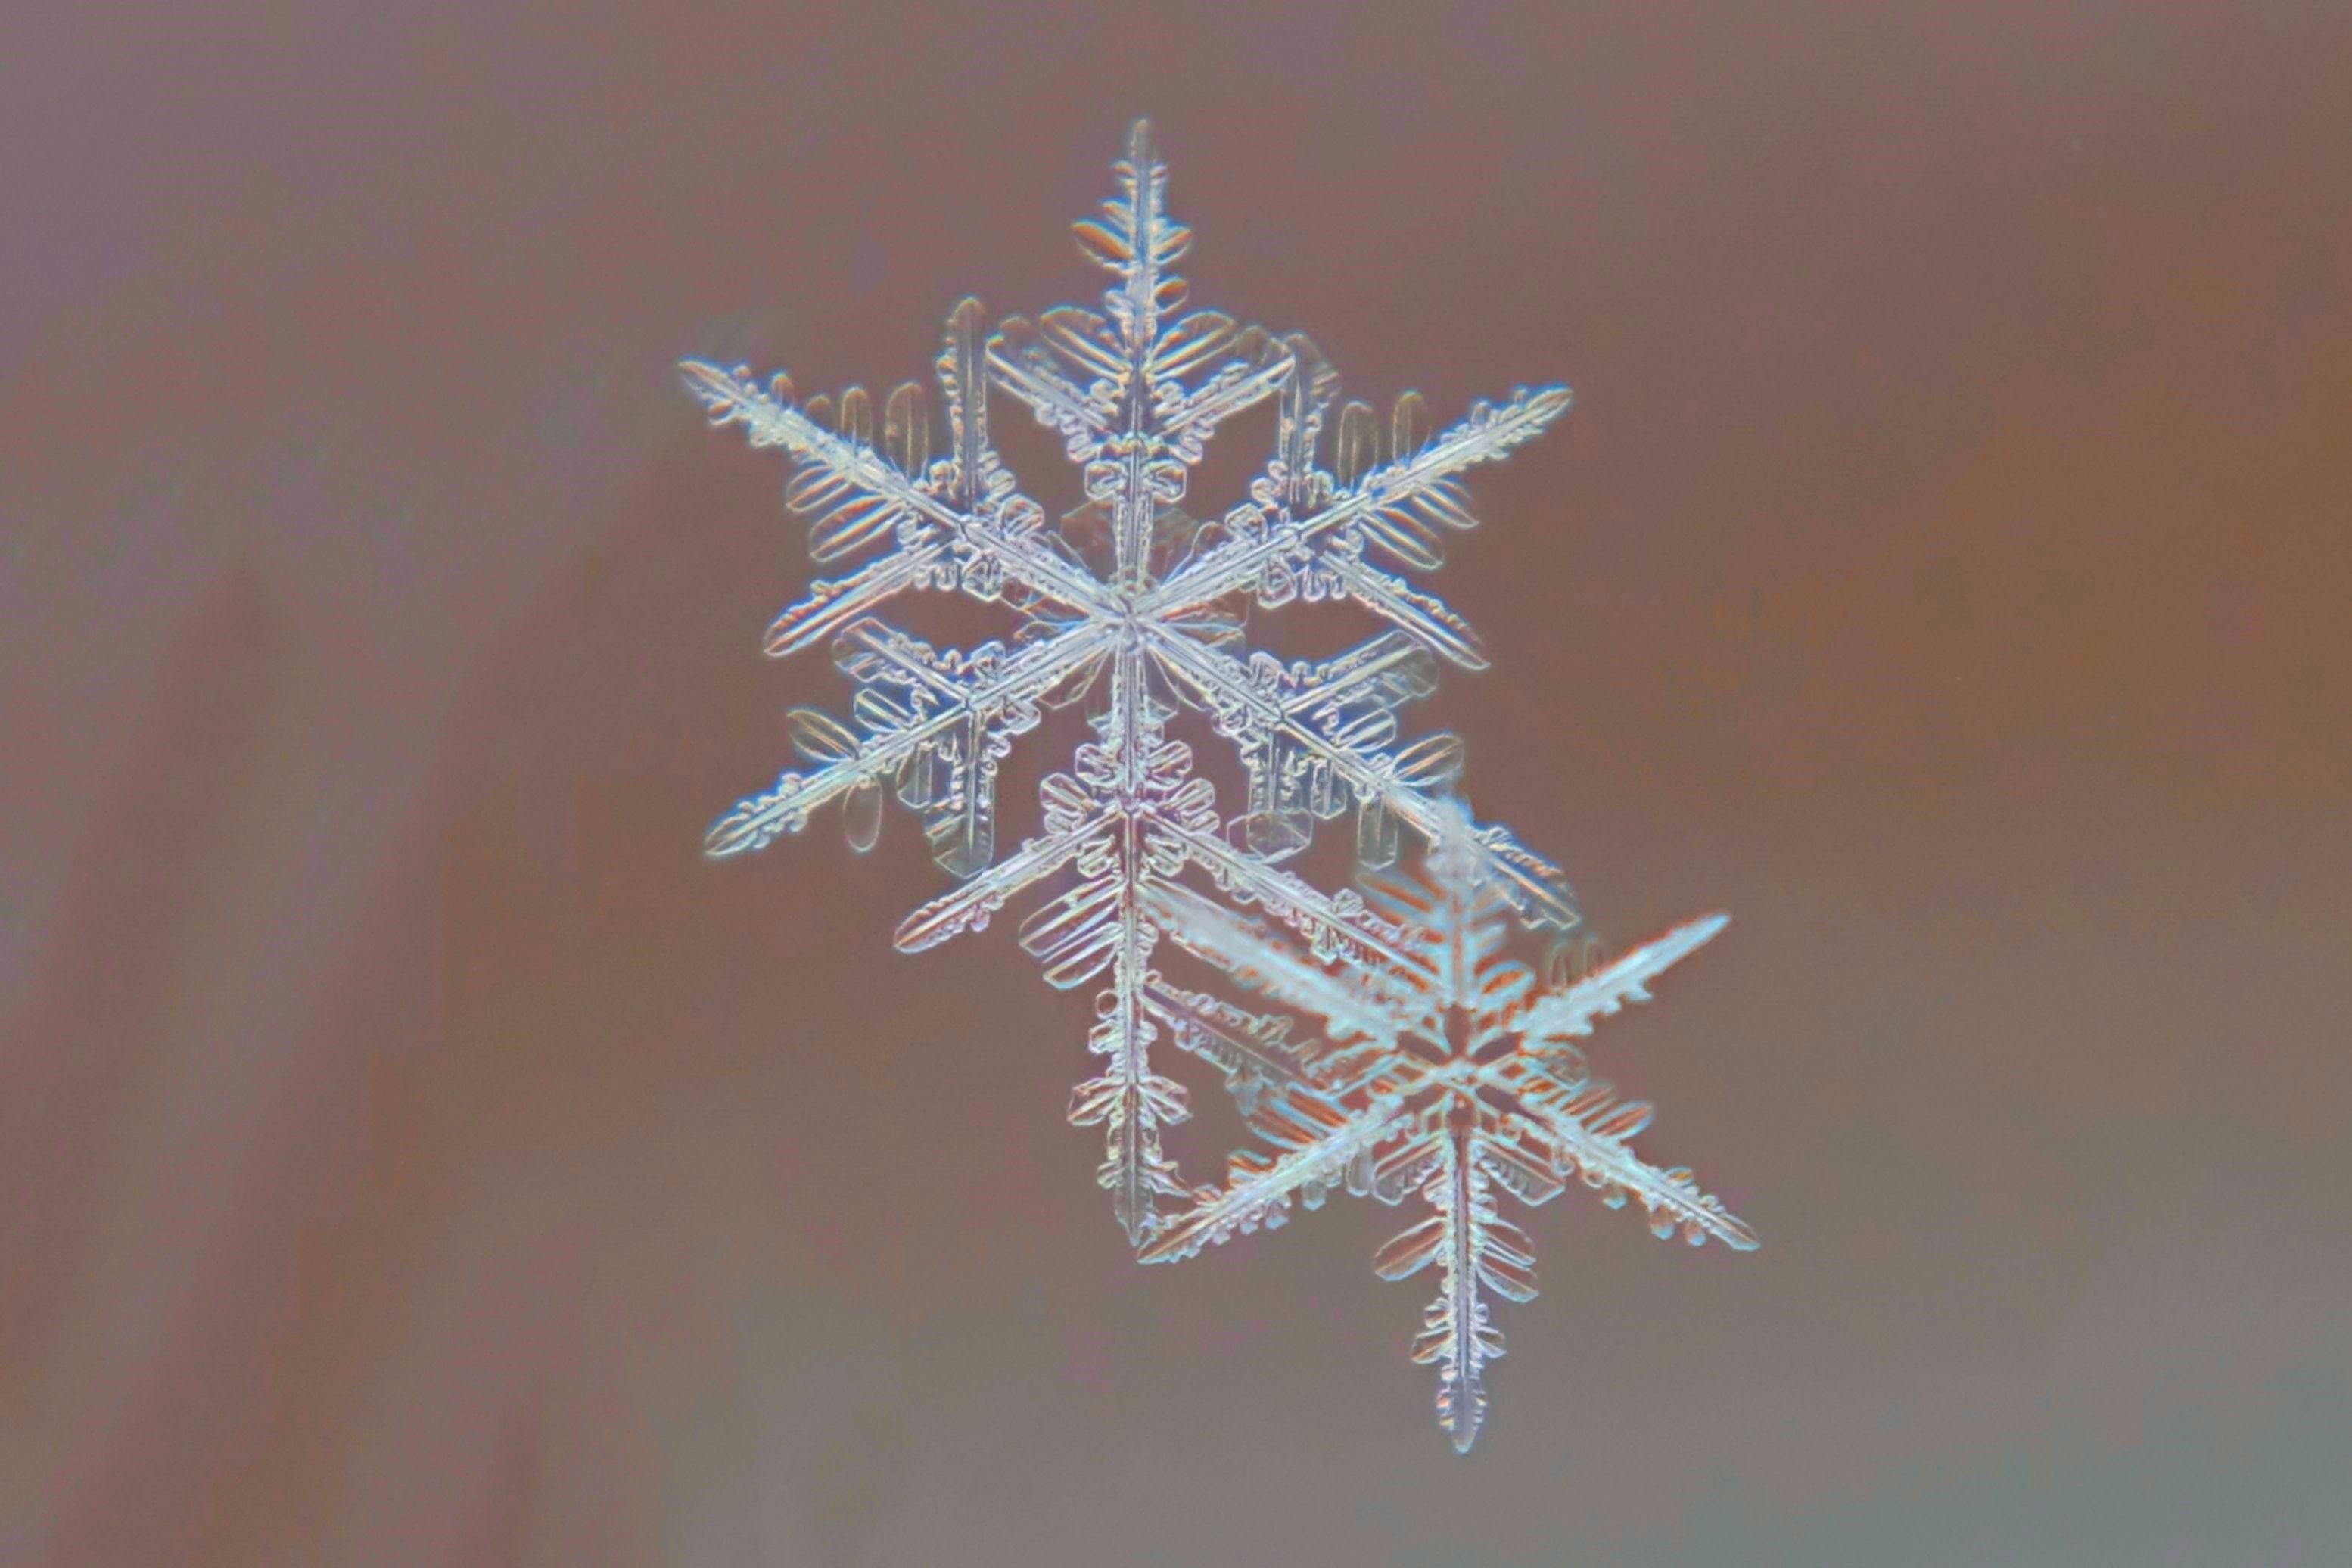

In [4]:
# Exibe a imagem no notebook para visualização
display(Image(filename="pexels-kristin-morgan-1853468-29636799.jpg"))

In [5]:
# Cria instância do módulo DSPy baseado na Signature
descritor = dspy.Predict(DescritorImagem)

# Executa o módulo: passa a imagem como entrada, recebe descrição como saída
# dspy.Image.from_path() carrega a imagem do disco e a prepara para o LLM
d = descritor(imagem=dspy.Image.from_path("pexels-kristin-morgan-1853468-29636799.jpg"))

# Imprime a descrição gerada pelo LLM
print(d.descricao)

- Descrição geral: imagem em macro/microfotografia mostrando um cristal de neve (floco de neve) transparente com simetria hexagonal, sobre um fundo uniforme desfocado em tons quentes (marrom/rosa). Um segundo floco parcialmente visível aparece sobreposto na parte inferior-direita.

- Objetos detectados:
  - Floco de neve principal (1): posição central-direita da imagem, cristal completo com seis braços (hexagonal), altamente detalhado.
  - Floco de neve secundário (1): parcialmente visível na parte inferior-direita, sobreposição parcial com o principal.

- Forma e estrutura:
  - Simetria: hexagonal com 6 braços radiais aproximadamente iguais, cada braço possui ramificações dendríticas finas e placas prismáticas.
  - Detalhes finos: arestas nítidas, sulcos e pequenas ramificações laterais regulares ao longo dos braços; presença de estruturas em escamas e colunas internas visíveis.
  - Orientação: eixo principal quase vertical; braços distribuídos radialmente a ~60° entre si.

- Cores e 